In [1]:
import torch

torch.save(model.state_dict(), "../outputs/model.pth")
print("Model saved!")

NameError: name 'model' is not defined

In [2]:
model = torchvision.models.resnet18(pretrained=True)
model.fc = nn.Linear(...)

NameError: name 'torchvision' is not defined

In [3]:
import torch
import torch.nn as nn
import torchvision

In [4]:
model = torchvision.models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 8)

c:\Users\csp\anaconda3\envs\origin\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\csp\anaconda3\envs\origin\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
import torchvision
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 8)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cpu


In [8]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [9]:
losses = []

In [10]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

NameError: name 'train_loader' is not defined

In [11]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class LandmarkDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        img_path = os.path.join(self.img_dir, row[0])  # image name column
        image = Image.open(img_path).convert("RGB")

        labels = row[1:].values.astype("float32")  # 8 coords

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(labels)

In [12]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [13]:
dataset = LandmarkDataset(
    csv_file="../dataset/role_challenge_dataset_ground_truth.csv",
    img_dir="../dataset/images",
    transform=transform
)

In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [15]:
print(dataset[0])

KeyError: 0

In [16]:
import pandas as pd

df = pd.read_csv("../dataset/role_challenge_dataset_ground_truth.csv")
print(df.columns)

Index(['image_name', 'ofd_1_x', 'ofd_1_y', 'ofd_2_x', 'ofd_2_y', 'bpd_1_x',
       'bpd_1_y', 'bpd_2_x', 'bpd_2_y'],
      dtype='str')


In [17]:
import os
import torch
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image

class LandmarkDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        # ✅ correct column name
        img_name = row["image_name"]

        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # ✅ all coordinates except image_name
        labels = row.drop("image_name").values.astype("float32")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(labels)

In [18]:
print(dataset[0][0].shape)   # image tensor
print(dataset[0][1].shape)   # labels

KeyError: 0

In [19]:
img_path = os.path.join(self.img_dir, row[0])

NameError: name 'self' is not defined

In [20]:
import inspect
print(inspect.getsource(LandmarkDataset))

OSError: source code not available

In [1]:
import torch
import torch.nn as nn
import torchvision
import pandas as pd
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [2]:
class LandmarkDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        img_name = row["image_name"]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        labels = row.drop("image_name").values.astype("float32")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(labels)

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [4]:
dataset = LandmarkDataset(
    csv_file="../dataset/role_challenge_dataset_ground_truth.csv",
    img_dir="../dataset/images",
    transform=transform
)

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [5]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([8, 3, 224, 224])
torch.Size([8, 8])


In [6]:
import torchvision
import torch.nn as nn

model = torchvision.models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 8)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(device)

cpu


In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [9]:
losses = []

In [10]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")

Epoch 1/10 | Loss: 138447.1173
Epoch 2/10 | Loss: 135160.3502
Epoch 3/10 | Loss: 131526.5561
Epoch 4/10 | Loss: 127419.4631
Epoch 5/10 | Loss: 123180.3601
Epoch 6/10 | Loss: 119025.8092
Epoch 7/10 | Loss: 114886.7201
Epoch 8/10 | Loss: 110828.2692
Epoch 9/10 | Loss: 106586.2268
Epoch 10/10 | Loss: 102548.0744


In [11]:
import torch

def mae(preds, targets):
    return torch.mean(torch.abs(preds - targets))

In [12]:
model.eval()

total_mae = 0

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        total_mae += mae(outputs, labels).item()

print("MAE:", total_mae / len(train_loader))

MAE: 273.2868980994591


In [13]:
labels = row.drop("image_name").values.astype("float32")

# normalize using image size assumption
# (based on your dataset scale)
labels[0::2] = labels[0::2] / 800.0  # x-coordinates
labels[1::2] = labels[1::2] / 600.0  # y-coordinates

NameError: name 'row' is not defined

In [14]:
def __getitem__(self, idx):
    row = self.annotations.iloc[idx]

In [15]:
labels = row.drop("image_name").values.astype("float32")

# normalize coordinates
labels[0::2] = labels[0::2] / 800.0
labels[1::2] = labels[1::2] / 600.0

NameError: name 'row' is not defined

In [16]:
import os
import torch
import torch.nn as nn
import torchvision
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [17]:
class LandmarkDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]

        # image
        img_name = row["image_name"]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        # labels (8 coords)
        labels = row.drop("image_name").values.astype("float32")

        # 🔥 NORMALIZATION (IMPORTANT)
        labels[0::2] = labels[0::2] / 800.0  # x
        labels[1::2] = labels[1::2] / 600.0  # y

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(labels)

In [18]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [19]:
dataset = LandmarkDataset(
    csv_file="../dataset/role_challenge_dataset_ground_truth.csv",
    img_dir="../dataset/images",
    transform=transform
)

train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [20]:
model = torchvision.models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(model.fc.in_features, 8)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [22]:
epochs = 10
losses = []

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f}")

Epoch 1/10 | Loss: 0.0953
Epoch 2/10 | Loss: 0.0127
Epoch 3/10 | Loss: 0.0081
Epoch 4/10 | Loss: 0.0059
Epoch 5/10 | Loss: 0.0047
Epoch 6/10 | Loss: 0.0044
Epoch 7/10 | Loss: 0.0036
Epoch 8/10 | Loss: 0.0034
Epoch 9/10 | Loss: 0.0030
Epoch 10/10 | Loss: 0.0030


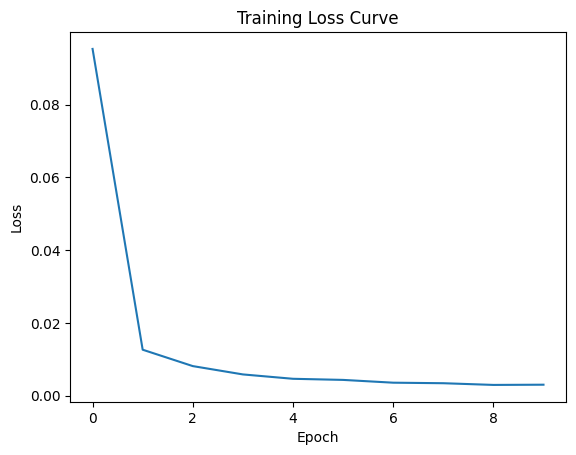

In [23]:
os.makedirs("../outputs", exist_ok=True)

plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("../outputs/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([8, 3, 224, 224])
torch.Size([8, 8])


In [25]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [26]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

In [27]:
with torch.no_grad():
    preds = model(images)

In [28]:
img = images[0].cpu().permute(1, 2, 0).numpy()
gt = labels[0].cpu().numpy()
pr = preds[0].cpu().numpy()

In [29]:
gt[0::2] *= 800
gt[1::2] *= 600

pr[0::2] *= 800
pr[1::2] *= 600

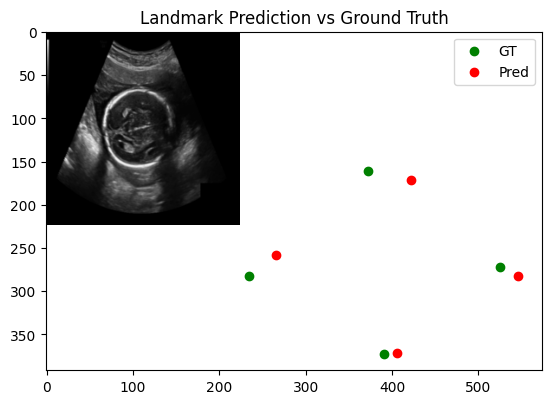

In [30]:
plt.imshow(img)

# ground truth (green)
plt.scatter(gt[0::2], gt[1::2], c="green", label="GT")

# prediction (red)
plt.scatter(pr[0::2], pr[1::2], c="red", label="Pred")

plt.legend()
plt.title("Landmark Prediction vs Ground Truth")

plt.savefig("../outputs/sample_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
import torch

model.eval()

total_mae = 0

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        preds = model(images)

        total_mae += torch.mean(torch.abs(preds - labels)).item()

print("Final MAE:", total_mae / len(train_loader))

Final MAE: 0.026683928755422432
